# Monte Carlo Simulation

Today we use **Monte Carlo** to price a **European call**: simulate many risk-neutral paths to maturity, take the average discounted payoff.

**Call value (discounted risk-neutral expectation)**

$$
C_0 \approx e^{-rT} \cdot \frac{1}{N} \sum_{i=1}^{N} \max\bigl(S_T^{(i)} - K,\, 0\bigr)
$$

**Terminal price** under geometric Brownian motion (GBM), with $Z_i \sim \mathcal{N}(0,1)$ i.i.d.:

$$
S_T^{(i)} = S_0 \exp\left(\left(r - \frac{\sigma^2}{2}\right)T + \sigma\sqrt{T}\, Z_i\right)
$$

**Notation**

- $S_0$ — current stock price  
- $K$ — strike price  
- $r$ — risk-free rate (continuously compounded)  
- $\sigma$ — volatility  
- $T$ — time to maturity  
- $N$ — number of simulated paths

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import yfinance as yf

#  Using Nvidia — spot and realized vol from market data
ticker = "NVDA"
hist = yf.Ticker(ticker).history(period="1y")
S0 = float(hist["Close"].iloc[-1])
close = hist["Close"].astype(float)
log_ret = np.log(close / close.shift(1)).dropna().to_numpy()
sigma = float(np.std(log_ret, ddof=1) * np.sqrt(252))  # annualized from daily log returns

K = S0 * 1.10  # strike ~10% above spot (same relative idea as the old 100 / 110 example)
r = 0.05       # risk-free rate (approximate; Treasury yields are closer for real desks)
T = 1.0        # time to maturity in years
N = 10000      # number of simulations (N)

print(f"{ticker}: spot ≈ ${S0:,.2f}, annualized hist. vol ≈ {sigma:.2%}")

np.random.seed(42)

Z = np.random.randn(N)
Z[:10]

TSLA: spot ≈ $367.96, annualized hist. vol ≈ 56.28%


array([ 0.49671415, -0.1382643 ,  0.64768854,  1.52302986, -0.23415337,
       -0.23413696,  1.57921282,  0.76743473, -0.46947439,  0.54256004])

In [ ]:
ST = S0 * np.exp((r - 0.5 * sigma**2) * T + sigma * np.sqrt(T) * Z)

print("First 10 simulated stock prices at maturity:")
print(ST[:10])

print("Average simulated stock price:", np.mean(ST))

First 10 simulated stock prices at maturity:
[436.65953642 305.45284666 475.38281259 778.0199479  289.40589384
 289.40856788 803.01329472 508.52386359 253.50772397 448.07262324]
Average simulated stock price: 386.84214278878545


In [3]:
payoff = np.maximum(ST - K, 0)
payoff[:10]

array([ 31.90354582,   0.        ,  70.62682199, 373.2639573 ,
         0.        ,   0.        , 398.25730412, 103.76787299,
         0.        ,  43.31663264])

In [ ]:
call_price = np.exp(-r * T) * np.mean(payoff)
print("Estimated European call option price::", call_price)

Estimated European call option price: 75.41131545841978


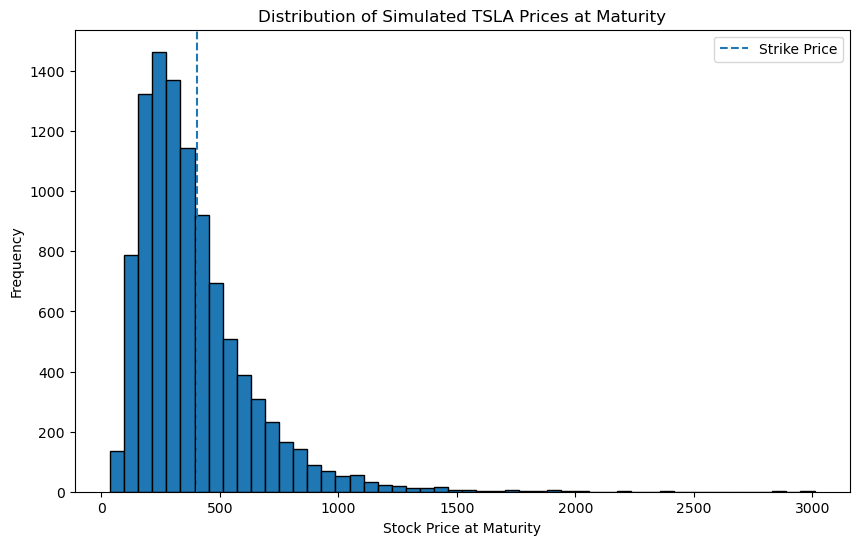

In [5]:
plt.figure(figsize=(10, 6))
plt.hist(ST, bins=50, edgecolor='black')
plt.axvline(K, linestyle='--', label='Strike Price')
plt.title(f'Distribution of Simulated {ticker} Prices at Maturity')
plt.xlabel('Stock Price at Maturity')
plt.ylabel('Frequency')
plt.legend()
plt.show()